# 🐍 Seaborn Visualization

## Learning goals
- Understand what Seaborn is and why it is useful.
- Learn basic Seaborn syntax.
- Create common statistical/data visualizations.
- Practice with a real dataset.
- Learn when to choose each plot.

**Teaching method:** Explain → Demonstrate → Student Practice → Mini Project → Challenge


## 1. What is Seaborn?

Seaborn is a Python library for **statistical data visualization**. It is built on top of Matplotlib and works especially well with Pandas DataFrames.

### Matplotlib vs Seaborn
- **Matplotlib:** general-purpose and highly customizable plotting.
- **Seaborn:** easier statistical/data-focused visualization with attractive defaults.


In [ ]:
# If needed, install Seaborn:
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt


## 2. First Seaborn Plot

Common pattern:

```python
sns.plot_function(data=df, x="column1", y="column2")
plt.show()
```


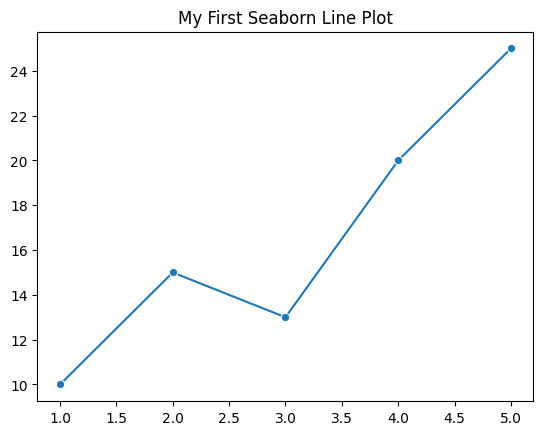

In [ ]:
x = [1, 2, 3, 4, 5]
y = [10, 15, 13, 20, 25]

sns.lineplot(x=y, y=y, marker="o")
plt.title("My First Seaborn Line Plot")
plt.show()


## 3. Load a Real Dataset

Seaborn provides small built-in datasets for learning. We will use the **tips** dataset.


In [ ]:
df = sns.load_dataset("tips")

print(df.head())



   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


In [ ]:
b = df.columns.tolist()
print(b)


['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [ ]:
print("\nShape:", df.shape)


Shape: (244, 7)


In [ ]:
print("\nColumns:", df.columns)


Columns: Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')


## 4. Line Plot — Trends

`sns.lineplot()` is useful for showing how a value changes across an ordered variable.


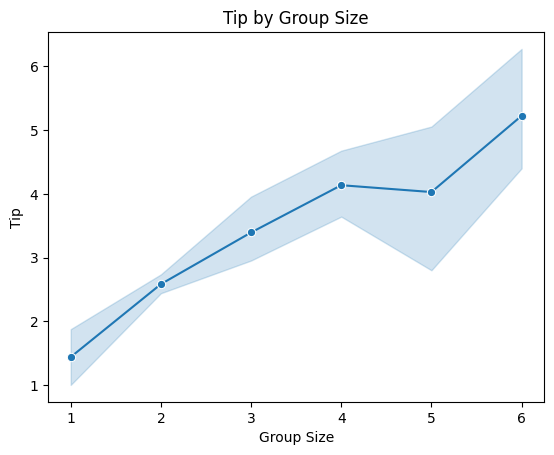

In [ ]:
sns.lineplot(data=df, x="size", y="tip", marker="o")
plt.title("Tip by Group Size")
plt.xlabel("Group Size")
plt.ylabel("Tip")
plt.show()


### Practice 1
Create a line plot using `total_bill` and `tip`. Add a title and axis labels.


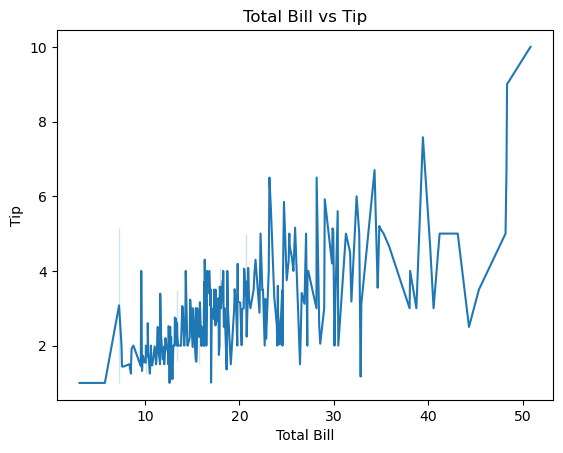

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

sns.lineplot(data=df, x="total_bill", y="tip")

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

## 5. Scatter Plot — Relationship

`sns.scatterplot()` helps us see the relationship between two numerical variables.


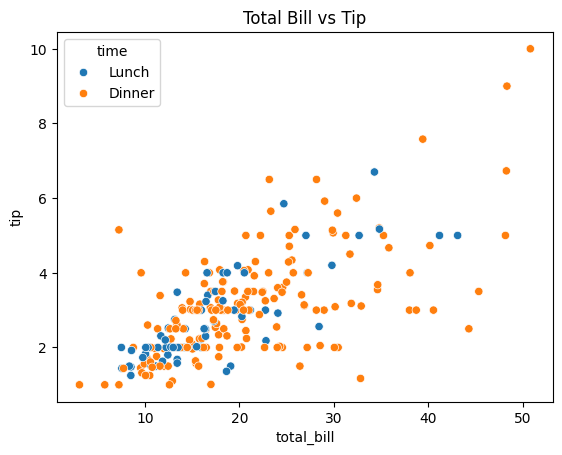

In [ ]:
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time")
plt.title("Total Bill vs Tip")
plt.show()


### Practice 2
Create a scatter plot of `total_bill` vs `tip` and use `sex` as the `hue`.


<Axes: xlabel='total_bill', ylabel='tip'>

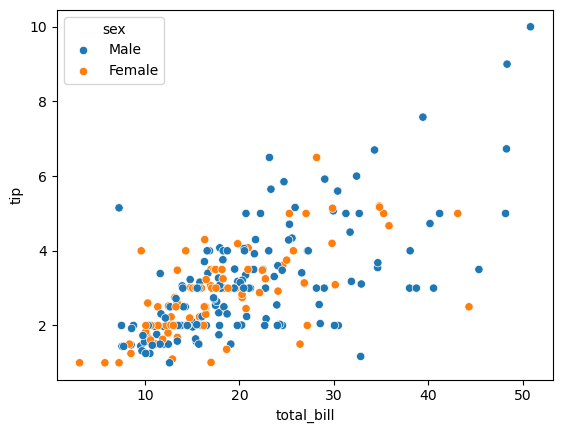

In [5]:
import seaborn as sns
df = sns.load_dataset("tips")
sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")

## 6. Bar Plot — Compare Categories

`sns.barplot()` compares a numerical value across categories. By default, it estimates the mean for each category.


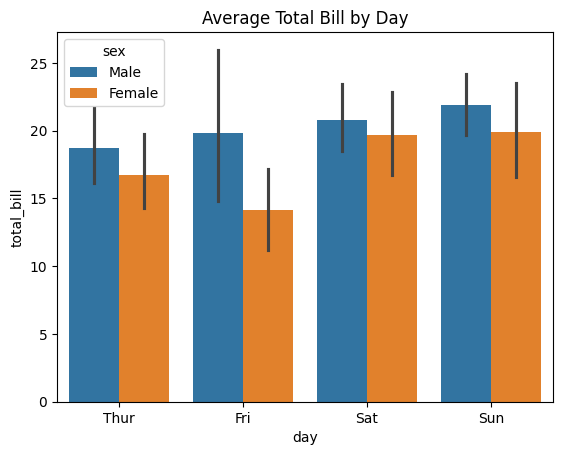

In [ ]:
sns.barplot(data=df, x="day", y="total_bill", hue="sex")
plt.title("Average Total Bill by Day")
plt.show()


### Practice 3
Create a bar plot comparing `tip` across `day`. Try using `hue="time"`.


<Axes: xlabel='day', ylabel='tip'>

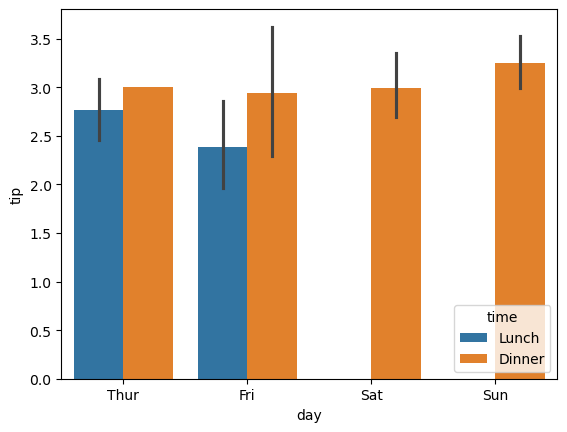

In [6]:
import seaborn as sns
df = sns.load_dataset("tips")
sns.barplot(data=df, x="day", y="tip", hue="time")


## 7. Histogram — Distribution

`sns.histplot()` shows how numerical values are distributed.


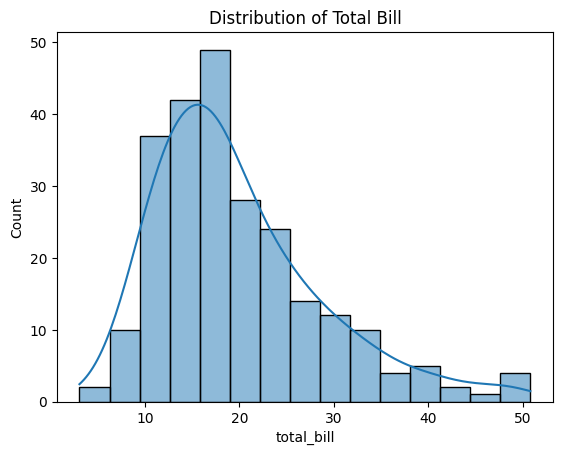

In [ ]:
sns.histplot(data=df, x="total_bill", bins=15, kde=True)
plt.title("Distribution of Total Bill")
plt.show()


The basic formula

For a data point \(x_i\), KDE uses:

$$ \hat f(x)=\frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x-x_i}{h}\right) $$

Don't worry about memorizing it for a beginner class.

Meaning:

Symbol	Meaning
\(x\)	Point where we want to calculate density
\(x_i\)	Actual data point
\(n\)	Number of data points
\(h\)	Bandwidth — controls smoothness
\(K\)	Kernel function, commonly Gaussian


### Practice 4
Create a histogram of `tip`. Try changing the number of bins.


<Axes: xlabel='tip', ylabel='Count'>

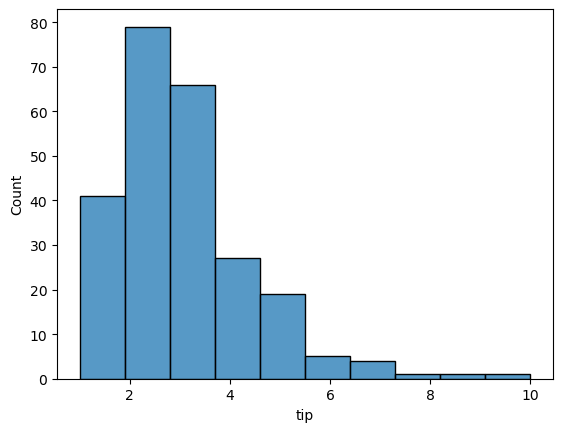

In [7]:
import seaborn  as sns
df = sns.load_dataset("tips")
sns.histplot(data=df, x="tip", bins=10)

## 8. Count Plot — Count Categories

`sns.countplot()` counts how many observations belong to each category.


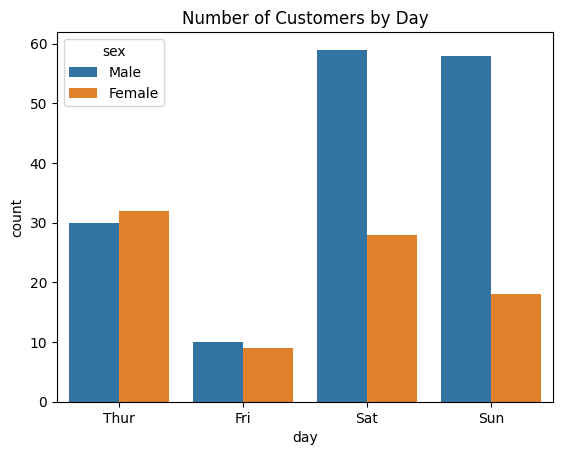

In [12]:
sns.countplot(data=df, x="day", hue="sex")
plt.title("Number of Customers by Day")
plt.show()


### Practice 5
Create a count plot for `time`. Then create one for `smoker`.


<Axes: xlabel='time', ylabel='count'>

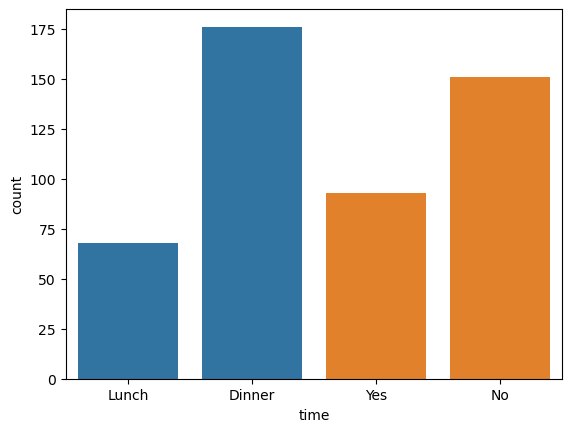

In [8]:
import seaborn as sns
df = sns.load_dataset("tips")
sns.countplot(data=df, x="time")
sns.countplot(data=df, x="smoker")

## 9. Box Plot — Spread and Outliers

A box plot helps show distribution, median, spread, and possible outliers.


What does a box plot show?

A box plot mainly shows five important values:

        Maximum
           |
           •
           |
       ────┐
           │
           │
       ────┤
       ────┤ ← Median
           │
           │
       ────┘
           |
        Minimum

These are called the five-number summary:

Value	Meaning
Minimum	Lower end of the data
Q1	25th percentile
Median	Middle value
Q3	75th percentile
Maximum	Upper end


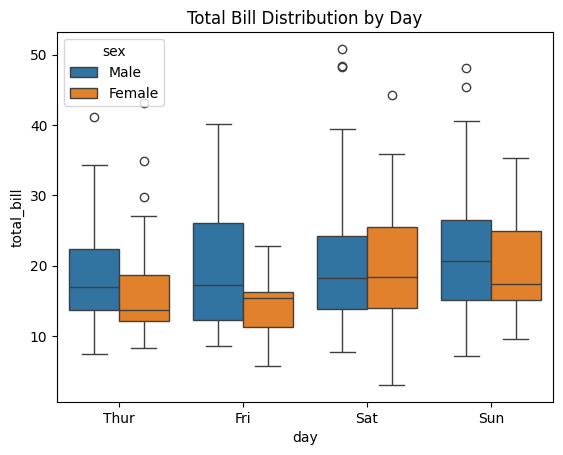

In [ ]:
sns.boxplot(data=df, x="day", y="total_bill", hue="sex")
plt.title("Total Bill Distribution by Day")
plt.show()


### Practice 6
Create a box plot of `tip` by `day`.


<Axes: xlabel='day', ylabel='tip'>

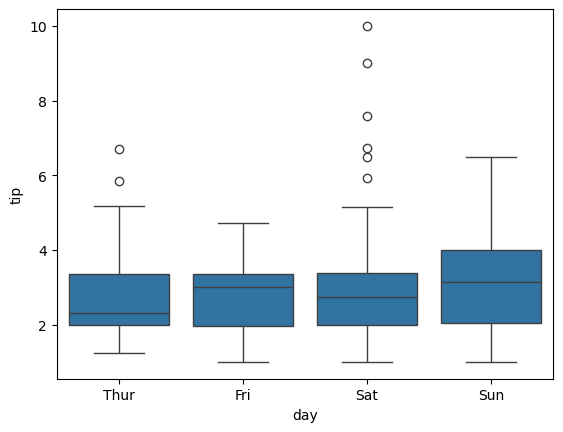

In [9]:
import seaborn as sns
df = sns.load_dataset("tips")
sns.boxplot(data=df, x="day", y="tip")

## 10. Heatmap — Matrix / Correlation

A heatmap uses color intensity to represent values in a matrix. A common data-science use is visualizing correlations.


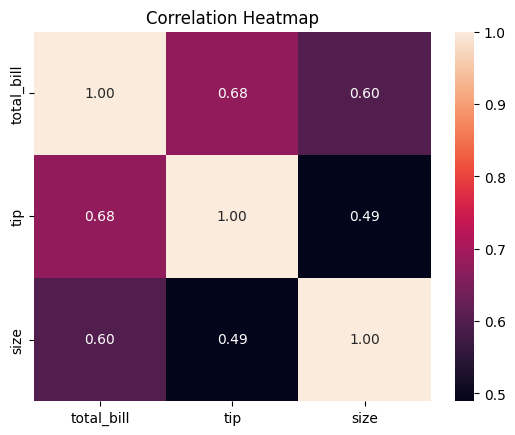

In [ ]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### Practice 7
Create a correlation heatmap using the numerical columns. Try `cmap="coolwarm"` as an optional customization.


<Axes: >

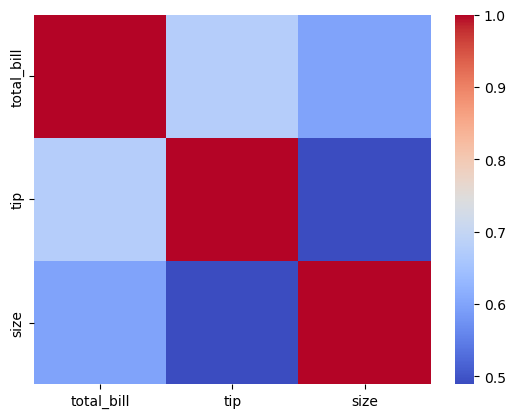

In [12]:
import seaborn as sns
df = sns.load_dataset("tips")
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm")

## 11. Pair Plot — Many Relationships

`sns.pairplot()` creates multiple plots to explore relationships between numerical variables.


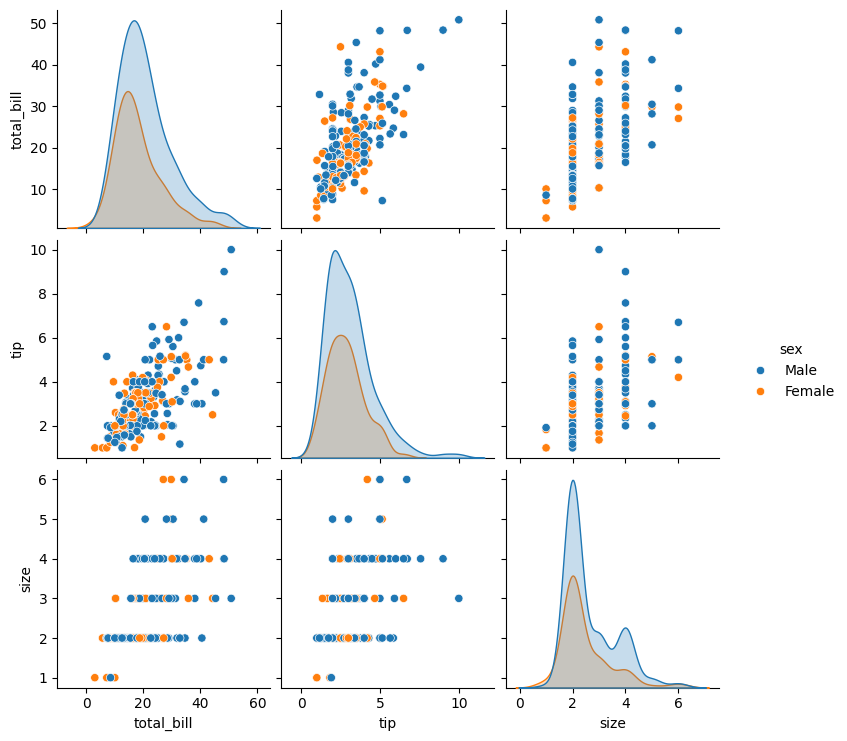

In [ ]:
sns.pairplot(df, hue="sex")
plt.show()


## 12. Quick Plot Selection Guide

| Question | Plot |
|---|---|
| How does a value change? | Line plot |
| Are two variables related? | Scatter plot |
| Which category has a higher value? | Bar plot |
| How are numerical values distributed? | Histogram |
| How many items are in each category? | Count plot |
| What is the spread and are there outliers? | Box plot |
| How strongly are numerical variables related? | Heatmap |
| What relationships exist across many variables? | Pair plot |


# 🧪 Mini Project — Restaurant Data Analysis

Using the `tips` dataset, answer:
1. Which day has the highest average total bill?
2. Does a larger total bill generally have a larger tip?
3. Which day has the most customers?
4. How are total bills distributed?
5. Are there unusual/outlier total bills?
6. Which numerical variables have stronger positive or negative correlation?

**Requirement:** Use at least 5 different Seaborn plot types and write one observation below each graph.


C:\Users\moonf\AppData\Local\Temp\ipykernel_16592\3068134486.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = df.groupby("day")["total_bill"].mean().reset_index()


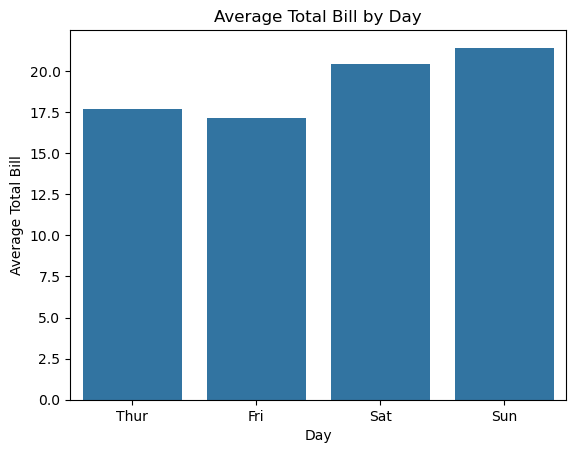

Observation: Sunday has the highest average total bill.


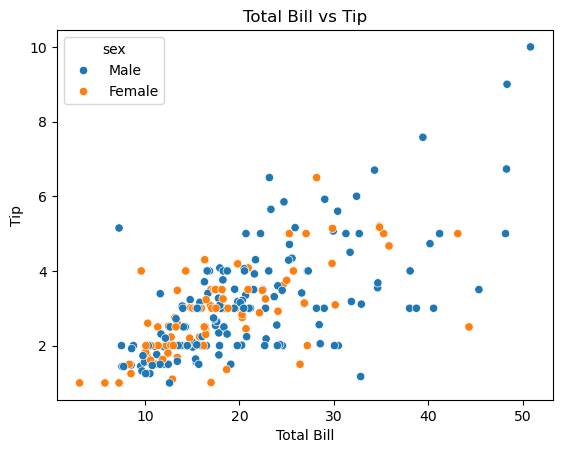

Observation: Larger total bills generally have larger tips, showing a positive relationship.


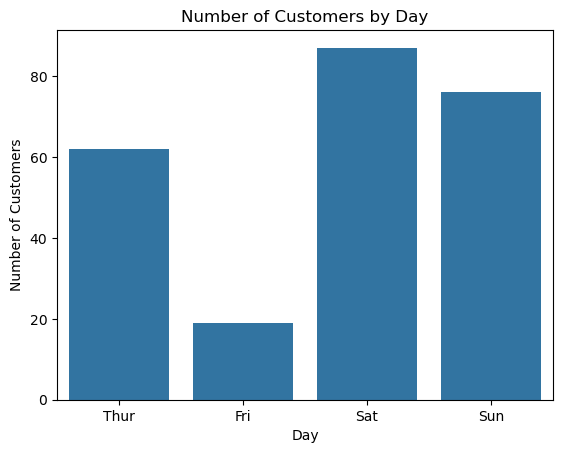

Observation: Saturday has the most customers.


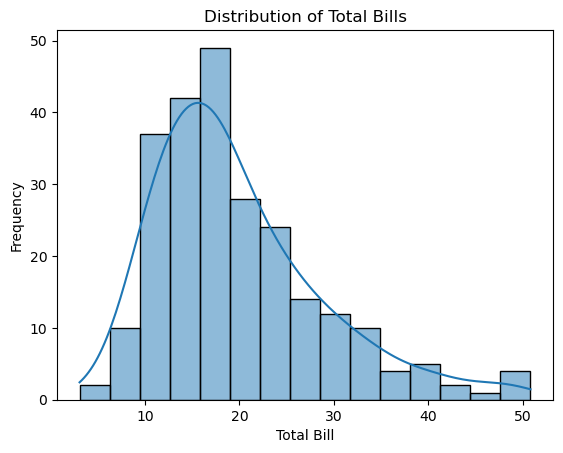

Observation: Most total bills are concentrated around the lower-to-middle range, with fewer very high bills.


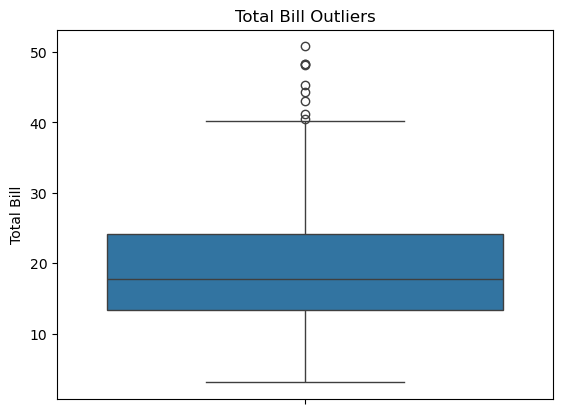

Observation: There are some unusually high total bills that appear as outliers.


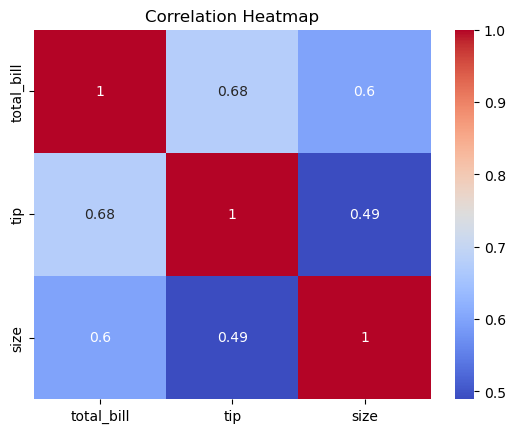

Observation: Total bill and tip have a strong positive correlation among the numerical variables.


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("tips")

avg_bill = df.groupby("day")["total_bill"].mean().reset_index()

sns.barplot(data=avg_bill, x="day", y="total_bill")
plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.show()

print("Observation: Sunday has the highest average total bill.")

sns.scatterplot(data=df, x="total_bill", y="tip", hue="sex")
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

print("Observation: Larger total bills generally have larger tips, showing a positive relationship.")

sns.countplot(data=df, x="day")
plt.title("Number of Customers by Day")
plt.xlabel("Day")
plt.ylabel("Number of Customers")
plt.show()

print("Observation: Saturday has the most customers.")

sns.histplot(data=df, x="total_bill", bins=15, kde=True)
plt.title("Distribution of Total Bills")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

print("Observation: Most total bills are concentrated around the lower-to-middle range, with fewer very high bills.")

sns.boxplot(data=df, y="total_bill")
plt.title("Total Bill Outliers")
plt.ylabel("Total Bill")
plt.show()

print("Observation: There are some unusually high total bills that appear as outliers.")

sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("Observation: Total bill and tip have a strong positive correlation among the numerical variables.")

# 🚀 Final Challenge

Create a small **Restaurant Dashboard in one notebook**.

Your dashboard should contain:
- 1 count plot
- 1 bar plot
- 1 scatter plot
- 1 histogram
- 1 box plot
- 1 correlation heatmap

For every graph, write one sentence explaining what you learned from it.


# 📝 Quick Revision

```python
sns.lineplot()
sns.scatterplot()
sns.barplot()
sns.histplot()
sns.countplot()
sns.boxplot()
sns.heatmap()
sns.pairplot()
```

**Remember:** Choose the graph based on the question you want to answer, not just because the graph looks good.


# 🎯 Optional Quiz Questions for the Teacher

1. What does `import seaborn as sns` do?
2. Which plot is useful for showing a relationship between two numerical variables?
3. Which function counts observations in categories?
4. Which plot is useful for detecting possible outliers?
5. What does `hue` do in many Seaborn plots?
6. What is the purpose of `sns.heatmap()`?
7. What does `sns.load_dataset("tips")` return?
8. What is one difference between Matplotlib and Seaborn?
